In [10]:
import nltk # Natural Language Toolkit
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
import pandas as pd
from text_cleaner import TextCleaner
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS
import seaborn as sns
import matplotlib.pyplot as plt
import re # Regular Expression
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
!pip install WordCloud
from wordcloud import WordCloud,STOPWORDS
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anuja\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anuja\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\anuja\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\anuja\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anuja\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [12]:
df = pd.read_excel("drugsCom_raw.xlsx")

In [14]:
df.head(10)

,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37
5,155963,Cialis,Benign Prostatic Hyperplasia,"""2nd day on 5mg started to work with rock hard...",2,2015-11-28,43
6,165907,Levonorgestrel,Emergency Contraception,"""He pulled out, but he cummed a bit in me. I t...",1,2017-03-07,5
7,102654,Aripiprazole,Bipolar Disorde,"""Abilify changed my life. There is hope. I was...",10,2015-03-14,32
8,74811,Keppra,Epilepsy,""" I Ve had nothing but problems with the Kepp...",1,2016-08-09,11
9,48928,Ethinyl estradiol / levonorgestrel,Birth Control,"""I had been on the pill for many years. When m...",8,2016-12-08,1


In [18]:
df = df.drop(['Unnamed: 0','rating','date','usefulCount'],axis = 1)

In [20]:
df.head(10)

,drugName,condition,review
0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati..."
1,Guanfacine,ADHD,"""My son is halfway through his fourth week of ..."
2,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh..."
3,Ortho Evra,Birth Control,"""This is my first time using any form of birth..."
4,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around..."
5,Cialis,Benign Prostatic Hyperplasia,"""2nd day on 5mg started to work with rock hard..."
6,Levonorgestrel,Emergency Contraception,"""He pulled out, but he cummed a bit in me. I t..."
7,Aripiprazole,Bipolar Disorde,"""Abilify changed my life. There is hope. I was..."
8,Keppra,Epilepsy,""" I Ve had nothing but problems with the Kepp..."
9,Ethinyl estradiol / levonorgestrel,Birth Control,"""I had been on the pill for many years. When m..."


In [22]:
filtered_df = df[df['condition'].isin(['Depression','High Blood Pressure','Diabetes, Type 2'])]
filtered_df = filtered_df.reset_index(drop=True)
print(filtered_df.index)

RangeIndex(start=0, stop=13944, step=1)


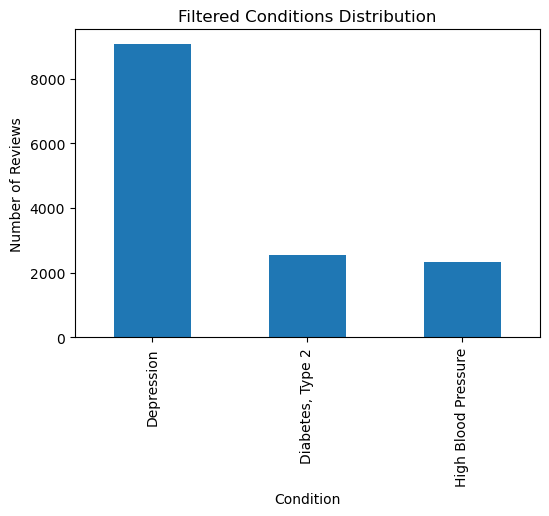

In [24]:
plt.figure(figsize=(6,4))
filtered_df['condition'].value_counts().plot(kind='bar')
plt.title("Filtered Conditions Distribution")
plt.xlabel("Condition")
plt.ylabel("Number of Reviews")
plt.show()
##Shows how many records each selected disease has

In [16]:
filtered_df.head(10)

,drugName,condition,review
0,L-methylfolate,Depression,"""I have taken anti-depressants for years, with..."
1,Sertraline,Depression,"""1 week on Zoloft for anxiety and mood swings...."
2,Venlafaxine,Depression,"""my gp started me on Venlafaxine yesterday to ..."
3,Dulaglutide,"Diabetes, Type 2","""Hey Guys, It&#039;s been 4 months since my l..."
4,Effexor XR,Depression,"""This medicine saved my life. I was at my wits..."
5,Wellbutrin,Depression,"""Started taking it and I slept well at night a..."
6,Aripiprazole,Depression,"""Intake Effexor XR 375 mg, and lorazepam for d..."
7,Amlodipine / olmesartan,High Blood Pressure,"""My blood pressure has been around 160/100. Do..."
8,Desvenlafaxine,Depression,"""This medication is amazing! After 3 days of b..."
9,Dulaglutide,"Diabetes, Type 2","""I was recently referred to a endocrinologist ..."


In [17]:
filtered_df.isnull().sum()

,0
drugName,0
condition,0
review,0


In [18]:
filtered_df.duplicated().sum()

np.int64(1)

In [19]:
filtered_df[filtered_df.duplicated()]

,drugName,condition,review
12413,Fluoxetine,Depression,"""I have suffered from severe depression/anxiet..."


In [20]:
filtered_df = filtered_df.drop_duplicates()

In [21]:
filtered_df.duplicated().sum()

np.int64(0)

In [22]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13943 entries, 0 to 13943
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   drugName   13943 non-null  object
 1   condition  13943 non-null  object
 2   review     13943 non-null  object
dtypes: object(3)
memory usage: 435.7+ KB


In [26]:
filtered_df['review_length'] = filtered_df['review'].apply(len)

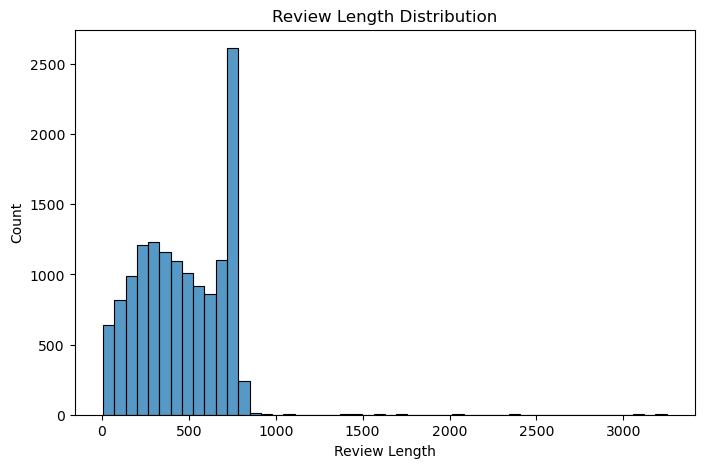

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(filtered_df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.show()

In [80]:
lemma = WordNetLemmatizer()

In [82]:
range(len(filtered_df))

range(0, 13944)

In [84]:
new = filtered_df['review'][0].split()
new

['"I',
 'have',
 'taken',
 'anti-depressants',
 'for',
 'years,',
 'with',
 'some',
 'improvement',
 'but',
 'mostly',
 'moderate',
 'to',
 'severe',
 'side',
 'affects,',
 'which',
 'makes',
 'me',
 'go',
 'off',
 'them.',
 'I',
 'only',
 'take',
 'Cymbalta',
 'now',
 'mostly',
 'for',
 'pain.',
 'When',
 'I',
 'began',
 'Deplin,',
 'I',
 'noticed',
 'a',
 'major',
 'improvement',
 'overnight.',
 'More',
 'energy,',
 'better',
 'disposition,',
 'and',
 'no',
 'sinking',
 'to',
 'the',
 'low',
 'lows',
 'of',
 'major',
 'depression.',
 'I',
 'have',
 'been',
 'taking',
 'it',
 'for',
 'about',
 '3',
 'months',
 'now',
 'and',
 'feel',
 'like',
 'a',
 'normal',
 'person',
 'for',
 'the',
 'first',
 'time',
 'ever.',
 'Best',
 'thing,',
 'no',
 'side',
 'effects."']

In [86]:
pd.set_option('display.max_colwidth', None)


In [88]:
filtered_df['drugName'] = filtered_df['drugName'].str.lower()

filtered_df['combined'] = filtered_df['drugName'] + " " + filtered_df['review']

In [90]:
filtered_df.head(10)

,drugName,condition,review,review_length,combined
0,l-methylfolate,Depression,"""I have taken anti-depressants for years, with some improvement but mostly moderate to severe side affects, which makes me go off them.\n\nI only take Cymbalta now mostly for pain.\n\nWhen I began Deplin, I noticed a major improvement overnight. More energy, better disposition, and no sinking to the low lows of major depression. I have been taking it for about 3 months now and feel like a normal person for the first time ever. Best thing, no side effects.""",456,"l-methylfolate ""I have taken anti-depressants for years, with some improvement but mostly moderate to severe side affects, which makes me go off them.\n\nI only take Cymbalta now mostly for pain.\n\nWhen I began Deplin, I noticed a major improvement overnight. More energy, better disposition, and no sinking to the low lows of major depression. I have been taking it for about 3 months now and feel like a normal person for the first time ever. Best thing, no side effects."""
1,sertraline,Depression,"""1 week on Zoloft for anxiety and mood swings. I take 50mg in the mornings with my breakfast. Nausea on day one but that subsided as the week went on. I get the jitters about 2 hrs after taking it followed by yawning. I feel much better though and less angry/stressed.""",271,"sertraline ""1 week on Zoloft for anxiety and mood swings. I take 50mg in the mornings with my breakfast. Nausea on day one but that subsided as the week went on. I get the jitters about 2 hrs after taking it followed by yawning. I feel much better though and less angry/stressed."""
2,venlafaxine,Depression,"""my gp started me on Venlafaxine yesterday to help with depression and the change,a hour after taking them i was feeling very sick couldn,t stomach food or fluids, thought keep it up as she told me they did come with some side effects which would get better,took another one last night and was so ill i couldn,t stand ,being sick sweating shaking thought i was going to pass out. Did get some sleep hopeing to feel better this morning,took another one and felt so spaced out dry mouth shaking ,sick, so booked in to see gp again to make sure i should be feeling like this, only to find out she had put me on the wrong dose should have been on 37.5mg was put on 150mg, now on right dose hope this will be better""",711,"venlafaxine ""my gp started me on Venlafaxine yesterday to help with depression and the change,a hour after taking them i was feeling very sick couldn,t stomach food or fluids, thought keep it up as she told me they did come with some side effects which would get better,took another one last night and was so ill i couldn,t stand ,being sick sweating shaking thought i was going to pass out. Did get some sleep hopeing to feel better this morning,took another one and felt so spaced out dry mouth shaking ,sick, so booked in to see gp again to make sure i should be feeling like this, only to find out she had put me on the wrong dose should have been on 37.5mg was put on 150mg, now on right dose hope this will be better"""
3,dulaglutide,"Diabetes, Type 2","""Hey Guys, It&#039;s been 4 months since my last post as I wanted to give it a few months to see how this was going to work. So, I have been on Trulicity for six months now with Metformin. When I hit the five month period the diarrhea, gas, sulphur belching finally subsided. I now longer have any of those side effects. However, I still haven&#039;t lost any weight at all, but I think that was because when I first started Trulicity I was taking it with Glimepiride and that one has a side effect of weight gain so I think the two meds were fighting each other lol. I have been back on the Metformin with Trulicity for about a week now, so we will see what this does. I was diagnosed as stage 3 chronic kidney disease (CKD 3) so I am watching diet closely.""",767,"dulaglutide ""Hey Guys, It&#039;s been 4 months since my last post as I wanted to give it a few months to see h

In [32]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

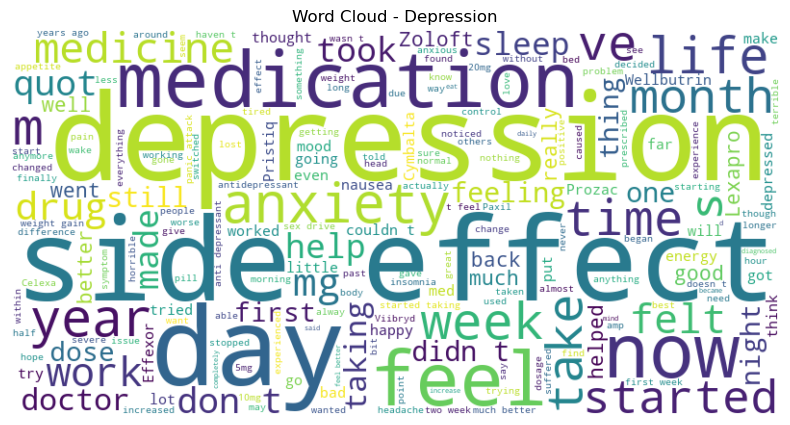

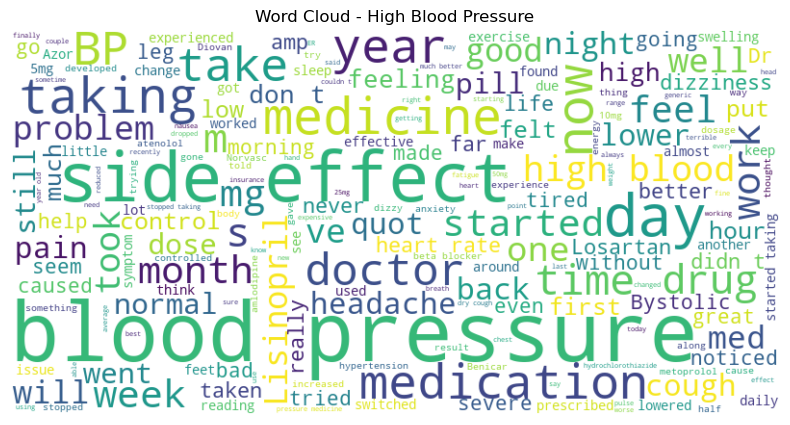

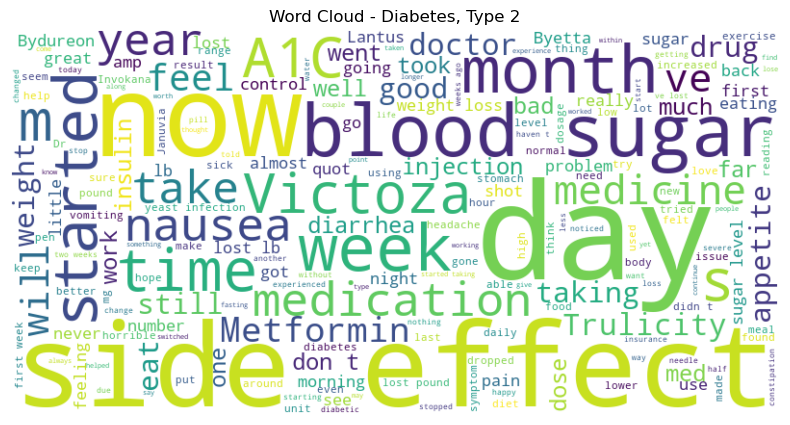

In [54]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

conditions = ['Depression','High Blood Pressure','Diabetes, Type 2']

for condition in conditions:

    subset = filtered_df[filtered_df['condition'] == condition]

    text = " ".join(subset['review'].dropna().astype(str))

    wordcloud = WordCloud(width=800,
                          height=400,
                          background_color='white').generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud - {condition}")
    plt.show()

In [29]:
#review_text = " ".join(filtered_df['clean_review'].astype(str))
#drug_text = " ".join(filtered_df['drugName'].astype(str))

In [30]:

#wc = WordCloud(background_color='grey').generate(review_text)
#plt.imshow(wc)#image show
#plt.axis('off')
#plt.title("DrugName",size=25)

In [31]:

#wc = WordCloud(background_color='grey').generate(drug_text)
#plt.imshow(wc)#image show
#plt.axis('off')
#plt.title("DrugName",size=25)

In [213]:
X = filtered_df['combined']
y = filtered_df['condition']



In [215]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))

X_vectorized = vectorizer.fit_transform(X)

In [216]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9770527070634636

Classification Report:

                     precision    recall  f1-score   support

         Depression       0.97      1.00      0.98      1800
   Diabetes, Type 2       1.00      0.97      0.98       501
High Blood Pressure       0.99      0.91      0.95       488

           accuracy                           0.98      2789
          macro avg       0.99      0.96      0.97      2789
       weighted avg       0.98      0.98      0.98      2789



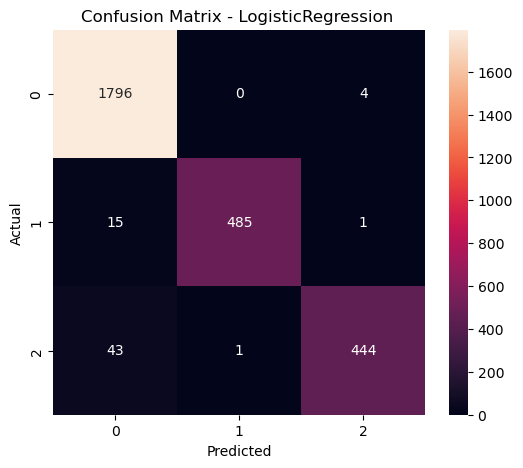

In [169]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - LogisticRegression ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [171]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9365363929723916

Classification Report:

                     precision    recall  f1-score   support

         Depression       0.91      1.00      0.95      1800
   Diabetes, Type 2       1.00      0.89      0.94       501
High Blood Pressure       0.99      0.75      0.86       488

           accuracy                           0.94      2789
          macro avg       0.97      0.88      0.92      2789
       weighted avg       0.94      0.94      0.93      2789



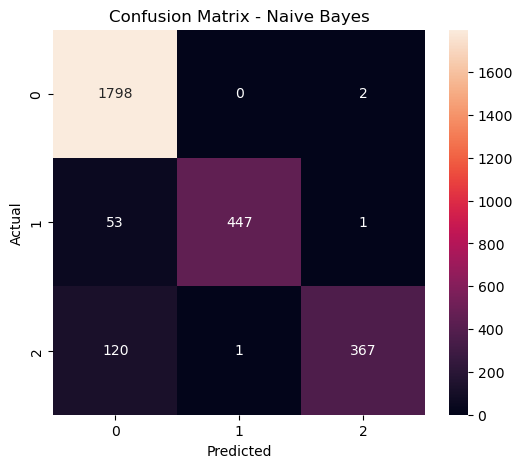

In [173]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

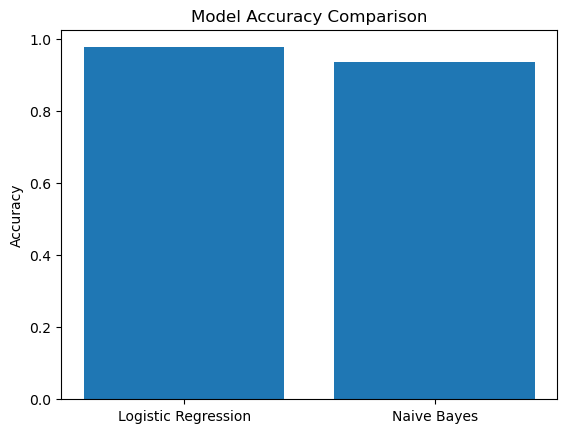

In [189]:
import matplotlib.pyplot as plt

models = ['Logistic Regression','Naive Bayes']
accuracy = [lr_acc, nb_acc]

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [191]:
accuracy_dict = {
    "Logistic Regression": lr_acc,
    "Naive Bayes": nb_acc,
    
}

best_model_name = max(accuracy_dict, key=accuracy_dict.get)

print("Best Model:", best_model_name)
print("Best Accuracy:", accuracy_dict[best_model_name])

Best Model: Logistic Regression
Best Accuracy: 0.9770527070634636


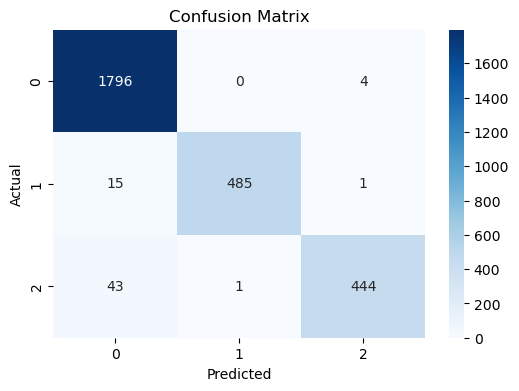

In [193]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [219]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('cleaner', TextCleaner()),
    ('tfidf', TfidfVectorizer()),
    ('model', LogisticRegression(max_iter=1000))
])

In [221]:
pipeline.fit(filtered_df['combined'], filtered_df['condition'])

Pipeline(steps=[('cleaner', TextCleaner()), ('tfidf', TfidfVectorizer()),
                ('model', LogisticRegression(max_iter=1000))])

In [223]:
import pickle

pickle.dump(pipeline, open("drug_condition_model.pkl", "wb"))

In [225]:
import pandas as pd
import joblib

df = pd.read_excel("drugsCom_raw.xlsx")

drug_list = df['drugName'].dropna().unique().tolist()

joblib.dump(drug_list, "drug_list.pkl")

['drug_list.pkl']